# EDA — Open Medic & BDPM
## Consommation antihistaminiques R06A en France (2021-2025)
**Notebook EDA — Membre 3**

Questions traitées :
1. Évolution du volume de boîtes prescrites et remboursées par année
2. Répartition par région
3. Répartition par tranche d'âge et sexe
4. Top molécules R06A remboursées (jointure BDPM)
5. Saisonnalité des ruptures par mois et par année
6. Coût de remboursement par boîte par molécule
7. Concentration du marché (courbe de Lorenz)
8. Heatmap région × molécule

In [1]:
import os
os.chdir('..')  # remonte de notebooks/ vers la racine du projet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# ── Chemins
PATH_OPENMEDIC = 'data/silver/J0_silver_openmedic_2021_2025.csv'
PATH_BDPM      = 'data/silver/J0_silver_bdpm.csv'
PATH_RUPTURES  = 'data/silver/J0_silver_ruptures.csv'

# ── Chargement
om   = pd.read_csv(PATH_OPENMEDIC, low_memory=False)
bdpm = pd.read_csv(PATH_BDPM)
rupt = pd.read_csv(PATH_RUPTURES)

# ── Mappings
REGIONS = {
    11: 'Île-de-France',      24: 'Centre-Val-de-Loire',
    27: 'Bourgogne-FC',       28: 'Normandie',
    32: 'Hauts-de-France',    44: 'Grand Est',
    52: 'Pays-de-la-Loire',   53: 'Bretagne',
    75: 'Nouvelle-Aquitaine', 76: 'Occitanie',
    84: 'Auvergne-RA',        93: 'PACA',
     5: 'Corse',              99: 'Hors région',  0: 'Non renseigné'
}
AGES  = {0: '0-19 ans', 20: '20-59 ans', 60: '60 ans et +', 99: 'Non renseigné'}
SEXES = {1: 'Homme', 2: 'Femme', 9: 'Non renseigné'}

om['region_nom'] = om['BEN_REG'].map(REGIONS)
om['age_label']  = om['age'].map(AGES)
om['sexe_label'] = om['sexe'].map(SEXES)

print(f'OpenMedic : {om.shape[0]:,} lignes x {om.shape[1]} colonnes')
print(f'BDPM      : {bdpm.shape[0]:,} lignes x {bdpm.shape[1]} colonnes')
print(f'Ruptures  : {rupt.shape[0]:,} lignes x {rupt.shape[1]} colonnes')
om.head(3)

OpenMedic : 258,174 lignes x 28 colonnes
BDPM      : 7,711 lignes x 7 colonnes
Ruptures  : 12,465 lignes x 15 colonnes


,ATC1,l_ATC1,ATC2,L_ATC2,ATC3,L_ATC3,ATC4,L_ATC4,ATC5,L_ATC5,...,BOITES,REM,BSE,annee,REM_clean,BSE_clean,AGE,region_nom,age_label,sexe_label
0,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,79,"85,89","199,87",2021,85.89,199.87,NaN,Hors région,20-59 ans,Homme
1,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,29,"30,36","73,37",2021,30.36,73.37,NaN,Hors région,20-59 ans,Femme
2,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,33,"13,88","92,51",2021,13.88,92.51,NaN,Hors région,60 ans et +,Femme


## 1. Évolution des boîtes prescrites et remboursées par année (2021-2025)

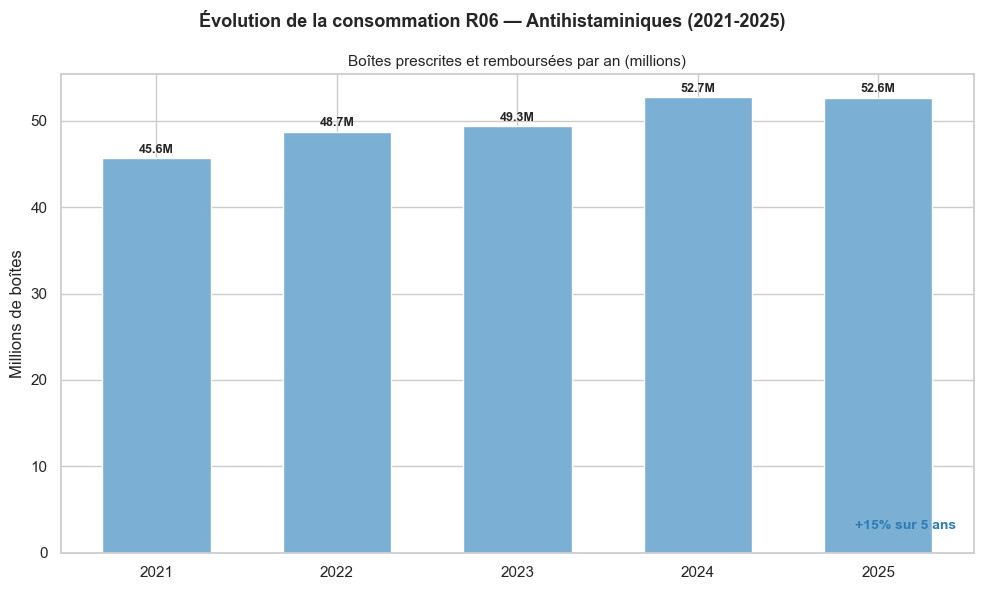

In [2]:
boites_annee = om.groupby('annee')['BOITES'].sum().reset_index()
boites_annee['BOITES_M'] = boites_annee['BOITES'] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Évolution de la consommation R06 — Antihistaminiques (2021-2025)',
             fontsize=13, fontweight='bold')

bars = ax.bar(boites_annee['annee'].astype(str), boites_annee['BOITES_M'],
              color='#7bafd4', edgecolor='white', width=0.6)
ax.set_title('Boîtes prescrites et remboursées par an (millions)', fontsize=11)
ax.set_ylabel('Millions de boîtes')
for bar, val in zip(bars, boites_annee['BOITES_M']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

pct = ((boites_annee['BOITES_M'].iloc[-1] - boites_annee['BOITES_M'].iloc[0])
       / boites_annee['BOITES_M'].iloc[0] * 100)
ax.text(0.98, 0.05, f'+{pct:.0f}% sur 5 ans', transform=ax.transAxes,
        ha='right', fontsize=10, color='#2c7bb6', fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_01_evolution_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Répartition par région

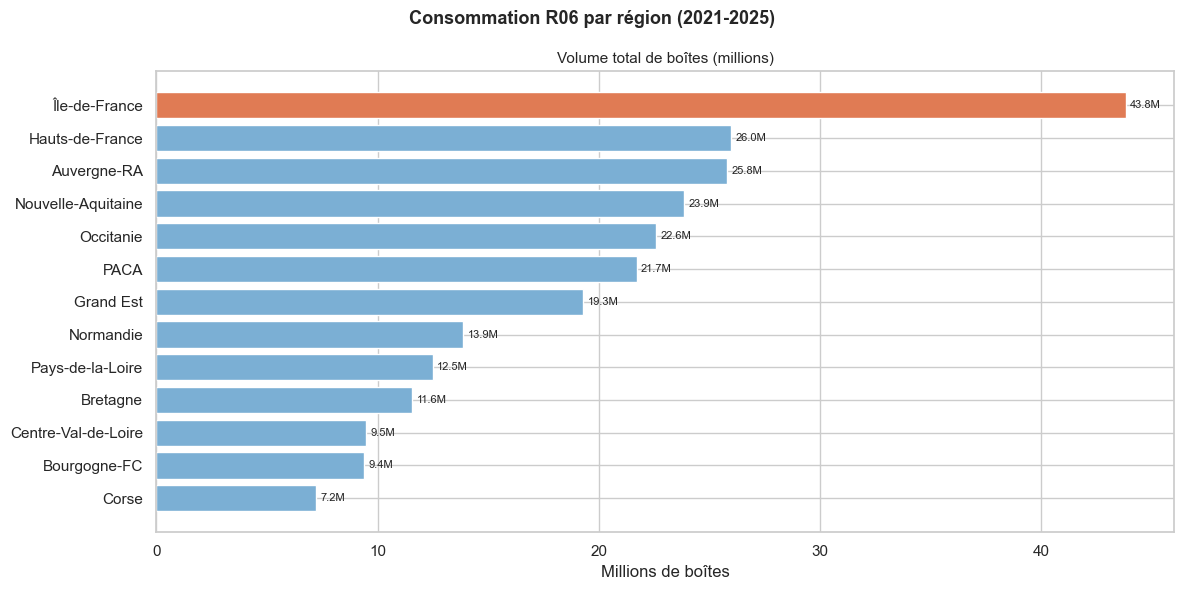

Top 5 régions :
        region_nom  BOITES_M       pct
     Île-de-France 43.805031 17.737387
   Hauts-de-France 25.960893 10.511998
       Auvergne-RA 25.780479 10.438946
Nouvelle-Aquitaine 23.854183  9.658956
         Occitanie 22.571532  9.139590


In [3]:
om_reg = om[~om['BEN_REG'].isin([0, 99])].copy()
boites_region = (om_reg.groupby('region_nom')['BOITES']
                 .sum().sort_values(ascending=True).reset_index())
boites_region['BOITES_M'] = boites_region['BOITES'] / 1e6
boites_region['pct'] = boites_region['BOITES'] / boites_region['BOITES'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Consommation R06 par région (2021-2025)', fontsize=13, fontweight='bold')

colors = ['#e07b54' if r == 'Île-de-France' else '#7bafd4' for r in boites_region['region_nom']]
bars = ax.barh(boites_region['region_nom'], boites_region['BOITES_M'],
               color=colors, edgecolor='white')
ax.set_title('Volume total de boîtes (millions)', fontsize=11)
ax.set_xlabel('Millions de boîtes')
for bar, val in zip(bars, boites_region['BOITES_M']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_02_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 régions :')
print(boites_region.nlargest(5, 'BOITES')[['region_nom','BOITES_M','pct']].to_string(index=False))

## 3. Répartition par tranche d'âge et sexe

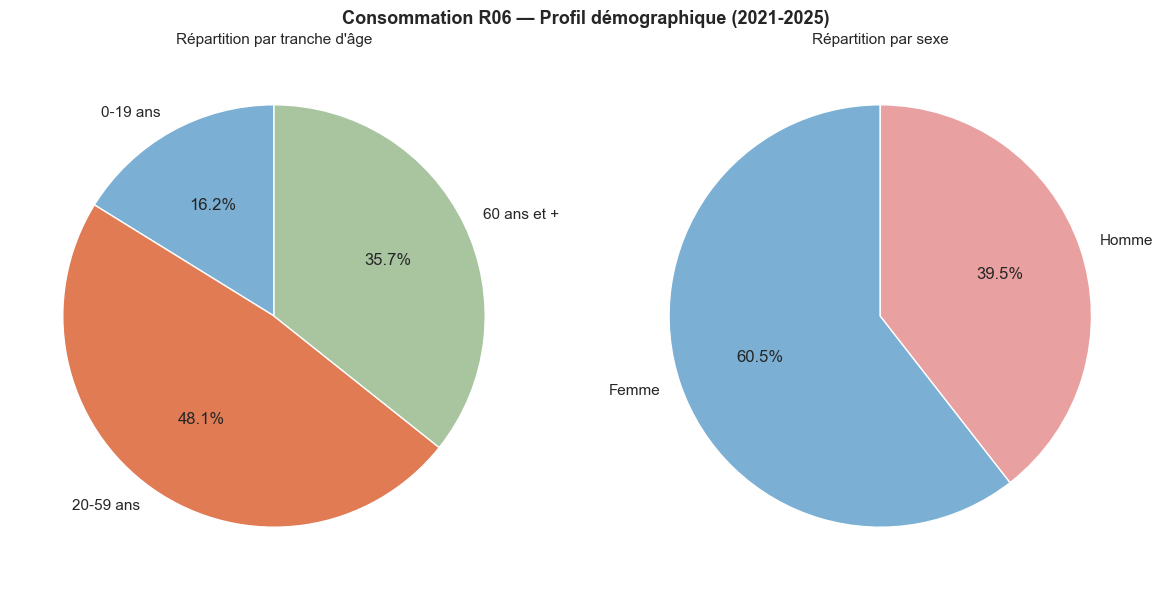

Répartition par âge :
  0-19 ans        : 16.2%
  20-59 ans       : 48.1%
  60 ans et +     : 35.7%

Répartition par sexe :
  Femme           : 60.5%
  Homme           : 39.5%


In [4]:
om_age  = om[om['age']  != 99].copy()
om_sexe = om[om['sexe'] != 9].copy()

boites_age  = om_age.groupby('age_label')['BOITES'].sum()
boites_sexe = om_sexe.groupby('sexe_label')['BOITES'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Consommation R06 — Profil démographique (2021-2025)",
             fontsize=13, fontweight='bold')

axes[0].pie(boites_age, labels=boites_age.index, autopct='%1.1f%%',
            startangle=90, colors=['#7bafd4','#e07b54','#a8c5a0'])
axes[0].set_title("Répartition par tranche d'âge", fontsize=11)

axes[1].pie(boites_sexe, labels=boites_sexe.index, autopct='%1.1f%%',
            startangle=90, colors=['#7bafd4','#e9a0a0'])
axes[1].set_title('Répartition par sexe', fontsize=11)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_03_demographie.png', dpi=150, bbox_inches='tight')
plt.show()

print("Répartition par âge :")
for label, val in (boites_age / boites_age.sum() * 100).items():
    print(f'  {label:15s} : {val:.1f}%')
print("\nRépartition par sexe :")
for label, val in (boites_sexe / boites_sexe.sum() * 100).items():
    print(f'  {label:15s} : {val:.1f}%')

## 4. Top molécules R06A remboursées — Jointure BDPM

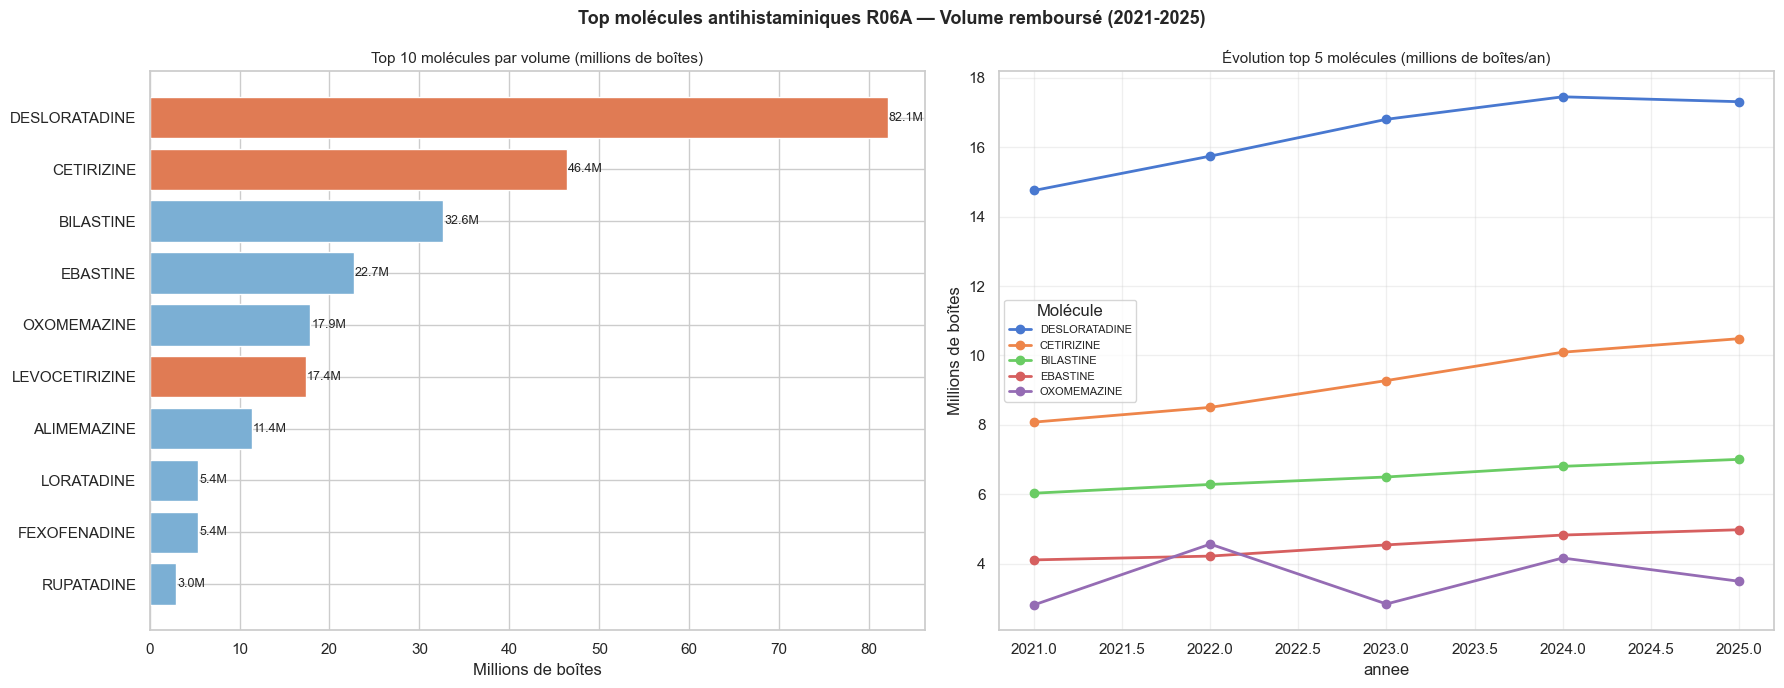

Top 10 molécules R06A :
        L_ATC5  BOITES_M                   substance_bdpm
 DESLORATADINE 82.067276                    DESLORATADINE
    CETIRIZINE 46.436545     DICHLORHYDRATE DE CÉTIRIZINE
     BILASTINE 32.624315                        BILASTINE
      EBASTINE 22.673215                         ÉBASTINE
   OXOMEMAZINE 17.876471                              NaN
LEVOCETIRIZINE 17.413210 DICHLORHYDRATE DE LÉVOCÉTIRIZINE
   ALIMEMAZINE 11.391435                              NaN
    LORATADINE  5.436911                       LORATADINE
  FEXOFENADINE  5.422772                              NaN
    RUPATADINE  2.973734                              NaN


In [5]:
boites_molecule = (om.groupby(['ATC5','L_ATC5'])['BOITES']
                   .sum().reset_index()
                   .sort_values('BOITES', ascending=False))
boites_molecule['BOITES_M'] = boites_molecule['BOITES'] / 1e6

bdpm_r06a = bdpm[bdpm['est_antihistaminique'] == True][['atc','substance']].copy()
bdpm_r06a['ATC5'] = bdpm_r06a['atc'].str[:7]
bdpm_mitm = bdpm_r06a.groupby('ATC5')['substance'].first().reset_index()
bdpm_mitm.columns = ['ATC5','substance_bdpm']
boites_molecule = boites_molecule.merge(bdpm_mitm, on='ATC5', how='left')

mol_annee = (om.groupby(['annee','L_ATC5'])['BOITES']
             .sum().unstack(fill_value=0) / 1e6)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top molécules antihistaminiques R06A — Volume remboursé (2021-2025)',
             fontsize=13, fontweight='bold')

top10 = boites_molecule.head(10).sort_values('BOITES_M')
colors_bar = ['#e07b54' if m in ['DESLORATADINE','CETIRIZINE','LEVOCETIRIZINE']
              else '#7bafd4' for m in top10['L_ATC5']]
bars = axes[0].barh(top10['L_ATC5'], top10['BOITES_M'], color=colors_bar, edgecolor='white')
axes[0].set_title('Top 10 molécules par volume (millions de boîtes)', fontsize=11)
axes[0].set_xlabel('Millions de boîtes')
for bar, val in zip(bars, top10['BOITES_M']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9)

top5_mol = boites_molecule.head(5)['L_ATC5'].tolist()
mol_top5 = mol_annee[[m for m in top5_mol if m in mol_annee.columns]]
mol_top5.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Évolution top 5 molécules (millions de boîtes/an)', fontsize=11)
axes[1].set_ylabel('Millions de boîtes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Molécule', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_04_molecules.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 molécules R06A :')
print(boites_molecule[['L_ATC5','BOITES_M','substance_bdpm']].head(10).to_string(index=False))

## 5. Saisonnalité des ruptures R06A par mois et par année

> **Limite connue** : OpenMedic ne contient pas de colonne mois — les données sont agrégées annuellement.
> Ce graphique utilise les données **ruptures ANSM** pour montrer la saisonnalité, pas les volumes OpenMedic.
> La jointure Gold (annee/mois/region) avec pollen et météo permettra de construire le signal mensuel complet.

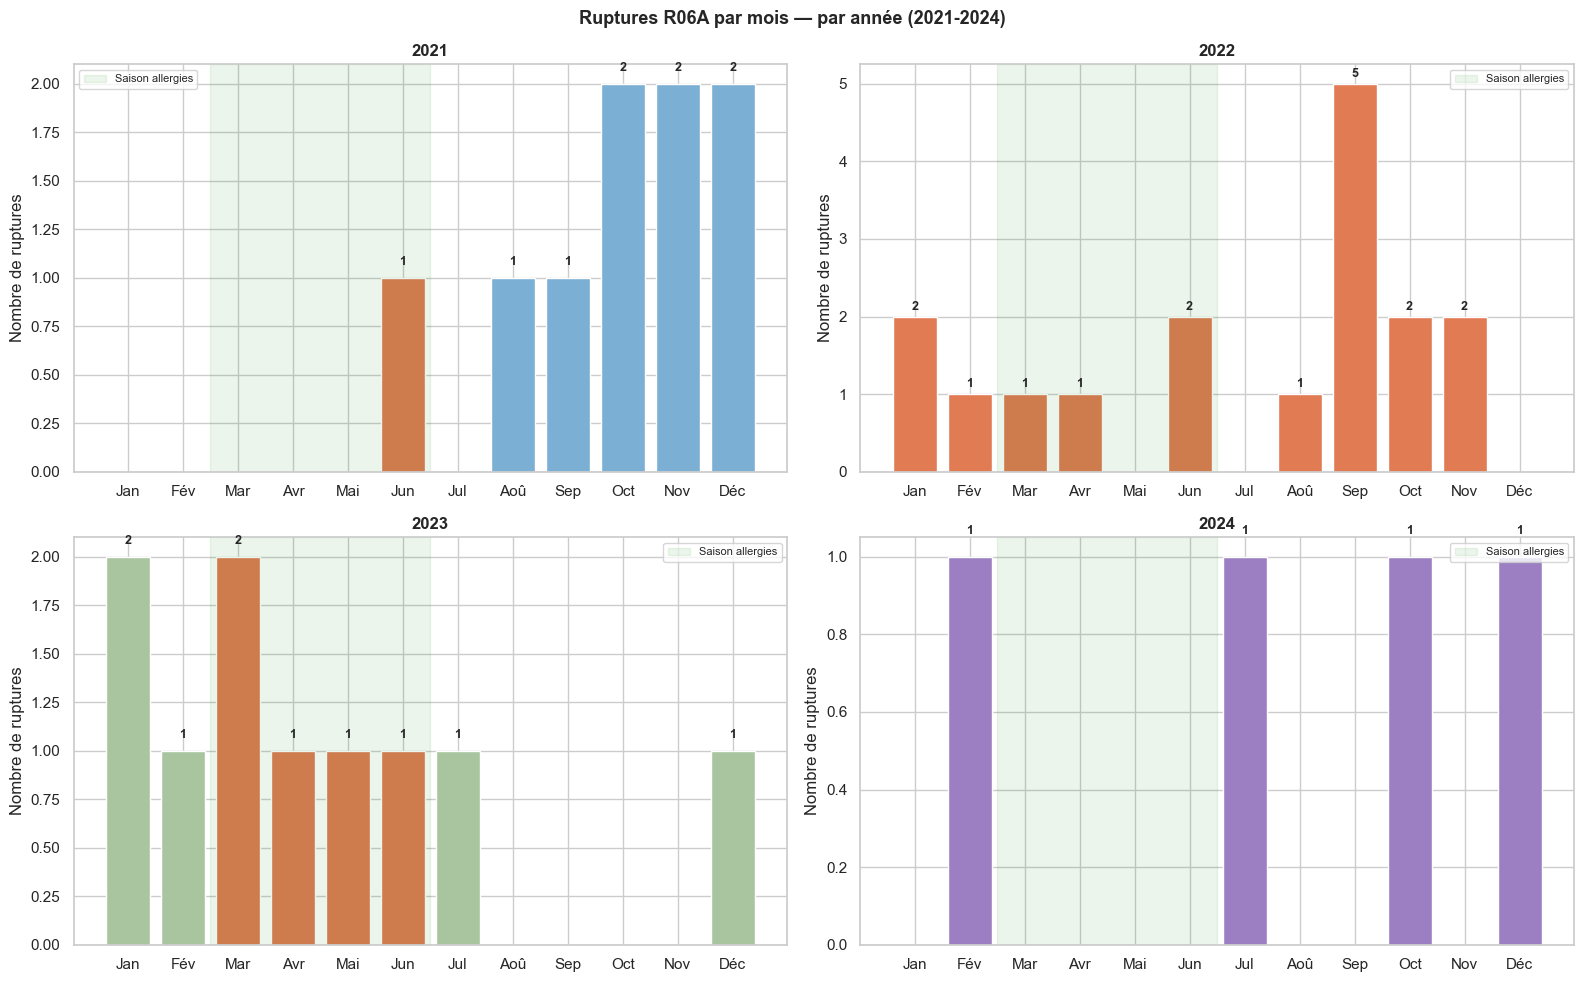

In [6]:
rupt_r06a = rupt[rupt['est_antihistaminique'] == True].copy()
rupt_r06a['date_evenement'] = pd.to_datetime(rupt_r06a['date_evenement'])

rupt_mois_annee = (rupt_r06a.groupby(['annee','mois']).size()
                   .reset_index(name='nb_ruptures'))

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
annees = sorted(rupt_mois_annee['annee'].unique())
colors_annee = ['#7bafd4','#e07b54','#a8c5a0','#9b7fc2']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ruptures R06A par mois — par année (2021-2024)',
             fontsize=13, fontweight='bold')

for ax, (annee, color) in zip(axes.flatten(), zip(annees, colors_annee)):
    data_annee = (rupt_mois_annee[rupt_mois_annee['annee'] == annee]
                  .set_index('mois')['nb_ruptures']
                  .reindex(range(1,13), fill_value=0))
    bar_colors = ['#e07b54' if m in [3,4,5,6] else color for m in range(1,13)]
    bars = ax.bar(mois_labels, data_annee.values, color=bar_colors, edgecolor='white')
    ax.set_title(f'{annee}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nombre de ruptures')
    ax.axvspan(1.5, 5.5, alpha=0.08, color='green', label='Saison allergies')
    for bar, val in zip(bars, data_annee.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_05_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

### Ce que les graphiques nous disent

**2021** — Les ruptures arrivent en fin d'année (Oct/Nov/Déc). Pas de signal pendant la saison allergique.
C'est probablement l'effet post-Covid — les chaînes d'approvisionnement étaient encore perturbées en automne 2021.

**2022** — C'est l'année la plus chargée avec un pic énorme en Septembre (5 ruptures).
Les ruptures sont présentes tout au long de l'année, y compris en saison allergique. C'est l'année qui ressemble le plus à ce qu'on attendrait.

**2023** — Les ruptures sont plus étalées et modérées. On voit un pic en Janvier et Mars (début saison).
Signal intéressant : les ruptures arrivent en amont de la saison, ce qui suggère que les stocks ont été anticipés mais pas suffisamment.

**2024** — Très peu de ruptures (4 au total), réparties aléatoirement. La tendance est clairement à la baisse.

### Insight ML
Il n'y a pas de pattern saisonnier clair et stable d'une année à l'autre.
Le signal pollen seul ne suffit probablement pas — il faut combiner avec d'autres variables (stocks, historique laboratoire, météo) pour prédire les ruptures.

## 6. Coût de remboursement par boîte par molécule

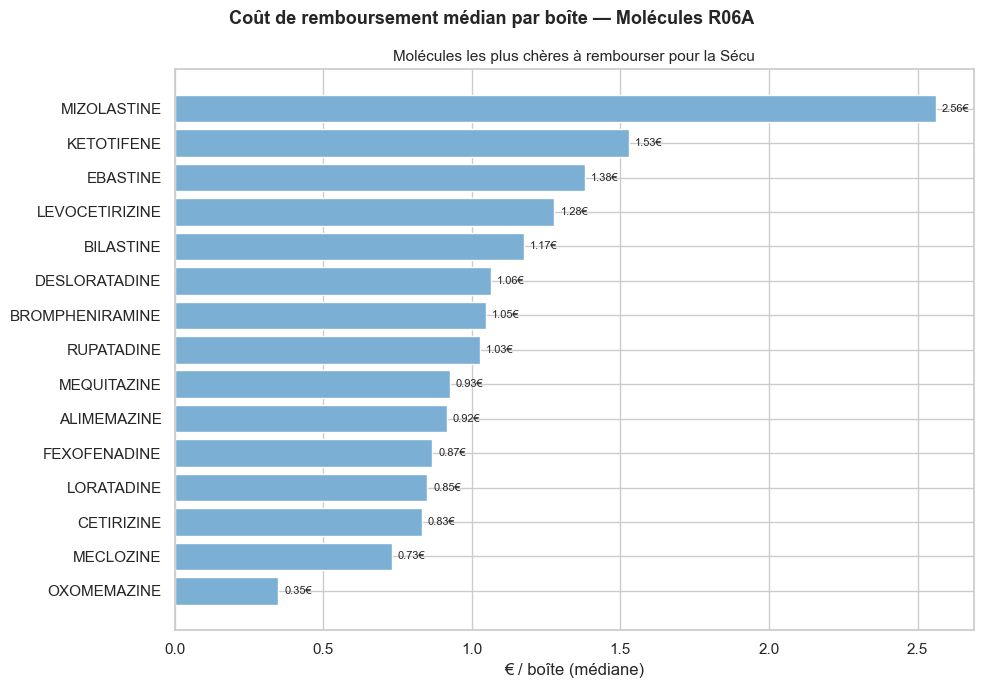

In [7]:
om['rem_par_boite'] = om['REM_clean'] / om['BOITES'].replace(0, np.nan)

ratio_mol = (om.groupby('L_ATC5')['rem_par_boite']
             .median()
             .sort_values(ascending=True)
             .reset_index())
ratio_mol.columns = ['molecule','rem_median_par_boite']

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Coût de remboursement médian par boîte — Molécules R06A',
             fontsize=13, fontweight='bold')

bars = ax.barh(ratio_mol['molecule'], ratio_mol['rem_median_par_boite'],
               color='#7bafd4', edgecolor='white')
ax.set_xlabel('€ / boîte (médiane)')
ax.set_title('Molécules les plus chères à rembourser pour la Sécu', fontsize=11)
for bar, val in zip(bars, ratio_mol['rem_median_par_boite']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}€', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_07_ratio_remboursement.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Concentration du marché — Courbe de Lorenz

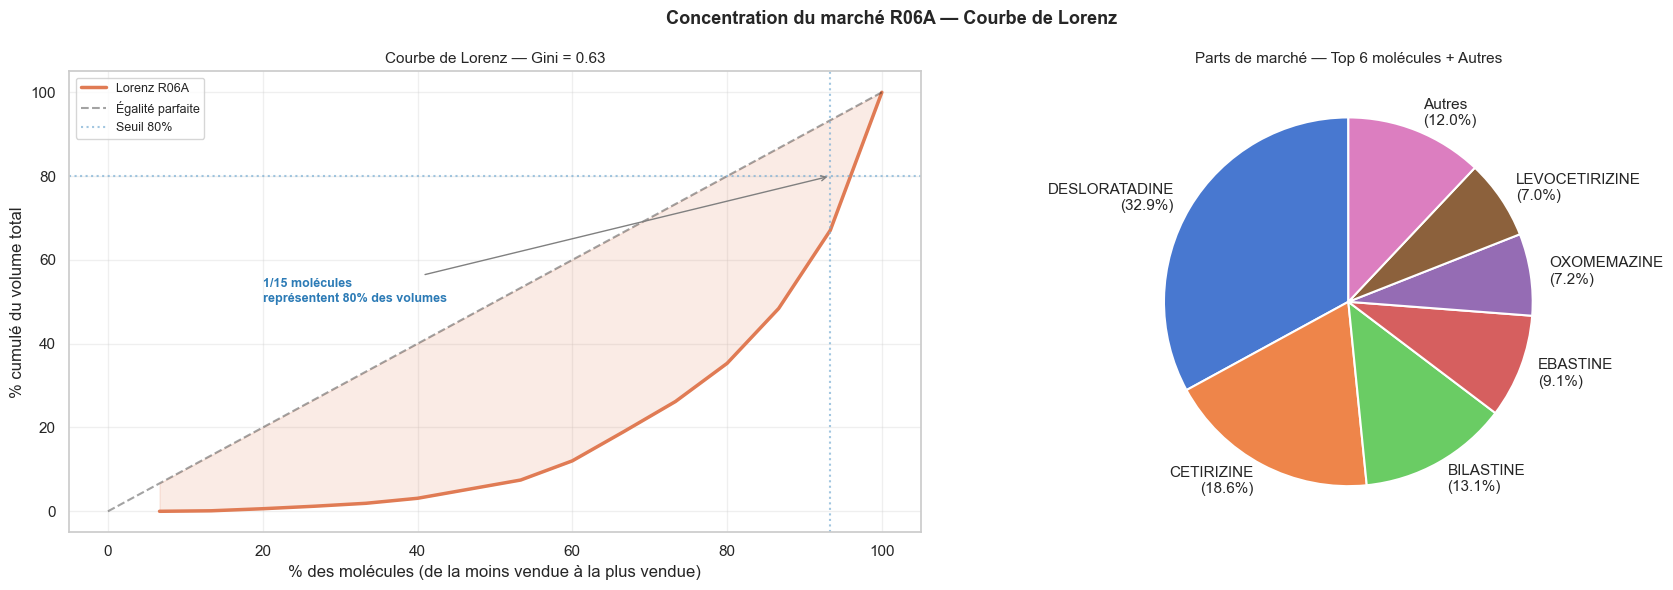

Indice de Gini : 0.630
1 molécules sur 15 représentent 80% des volumes
→ Marché très concentré : rupture d'une molécule dominante = impact fort ⚠


In [8]:
volumes_sorted = boites_molecule['BOITES'].sort_values().values
cumsum = np.cumsum(volumes_sorted)
cumsum_pct = cumsum / cumsum[-1] * 100
n = len(cumsum_pct)
x_pct = np.arange(1, n+1) / n * 100

gini = 1 - 2 * np.trapz(cumsum_pct/100, x_pct/100)

idx_80 = np.searchsorted(cumsum_pct, 80)
n_mol_80 = n - idx_80
pct_mol_80 = n_mol_80 / n * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Concentration du marché R06A — Courbe de Lorenz',
             fontsize=13, fontweight='bold')

axes[0].plot(x_pct, cumsum_pct, color='#e07b54', linewidth=2.5, label='Lorenz R06A')
axes[0].plot([0,100], [0,100], 'k--', alpha=0.4, label='Égalité parfaite')
axes[0].axhline(80, color='#7bafd4', linestyle=':', alpha=0.7, label='Seuil 80%')
axes[0].axvline(100 - pct_mol_80, color='#7bafd4', linestyle=':', alpha=0.7)
axes[0].fill_between(x_pct, cumsum_pct, x_pct, alpha=0.15, color='#e07b54')
axes[0].set_xlabel('% des molécules (de la moins vendue à la plus vendue)')
axes[0].set_ylabel('% cumulé du volume total')
axes[0].set_title(f'Courbe de Lorenz — Gini = {gini:.2f}', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'{n_mol_80}/{n} molécules\nreprésentent 80% des volumes',
                 xy=(100-pct_mol_80, 80), xytext=(20, 50),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9, color='#2c7bb6', fontweight='bold')

top_n = boites_molecule.head(6).copy()
autres_vol = boites_molecule.iloc[6:]['BOITES'].sum() / 1e6
top_n_plot = pd.concat([top_n[['L_ATC5','BOITES_M']],
                        pd.DataFrame({'L_ATC5':['Autres'],'BOITES_M':[autres_vol]})])
top_n_plot['pct'] = top_n_plot['BOITES_M'] / top_n_plot['BOITES_M'].sum() * 100

axes[1].pie(
    top_n_plot['BOITES_M'],
    labels=[f"{r['L_ATC5']}\n({r['pct']:.1f}%)" for _, r in top_n_plot.iterrows()],
    autopct='',
    startangle=90,
    colors=sns.color_palette('muted', len(top_n_plot)),
    wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Parts de marché — Top 6 molécules + Autres', fontsize=11)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_08_lorenz.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Indice de Gini : {gini:.3f}')
print(f'{n_mol_80} molécules sur {n} représentent 80% des volumes')
if gini > 0.5:
    print('→ Marché très concentré : rupture d\'une molécule dominante = impact fort ⚠')

La courbe de Lorenz mesure la concentration du marché : est-ce que quelques molécules représentent la majorité des volumes ?

**Comment lire ce graphique :**
- L'axe X = les molécules triées de la moins vendue à la plus vendue (en %)
- L'axe Y = le volume cumulé en % du total
- La **diagonale pointillée** = égalité parfaite (toutes les molécules se vendraient autant)
- Plus la courbe rouge est éloignée de la diagonale → plus le marché est concentré

**L'indice de Gini** résume l'écart en un seul chiffre : 0 = égalité parfaite, 1 = concentration totale.

**Ce que ça dit pour la soutenance :**
Un Gini élevé signifie que si la molécule dominante (Desloratadine, 33% du marché) entre en rupture,
un tiers des patients allergiques est impacté. C'est l'argument métier central pour justifier votre système de prédiction.

## 8. Volume par région × molécule — Heatmap

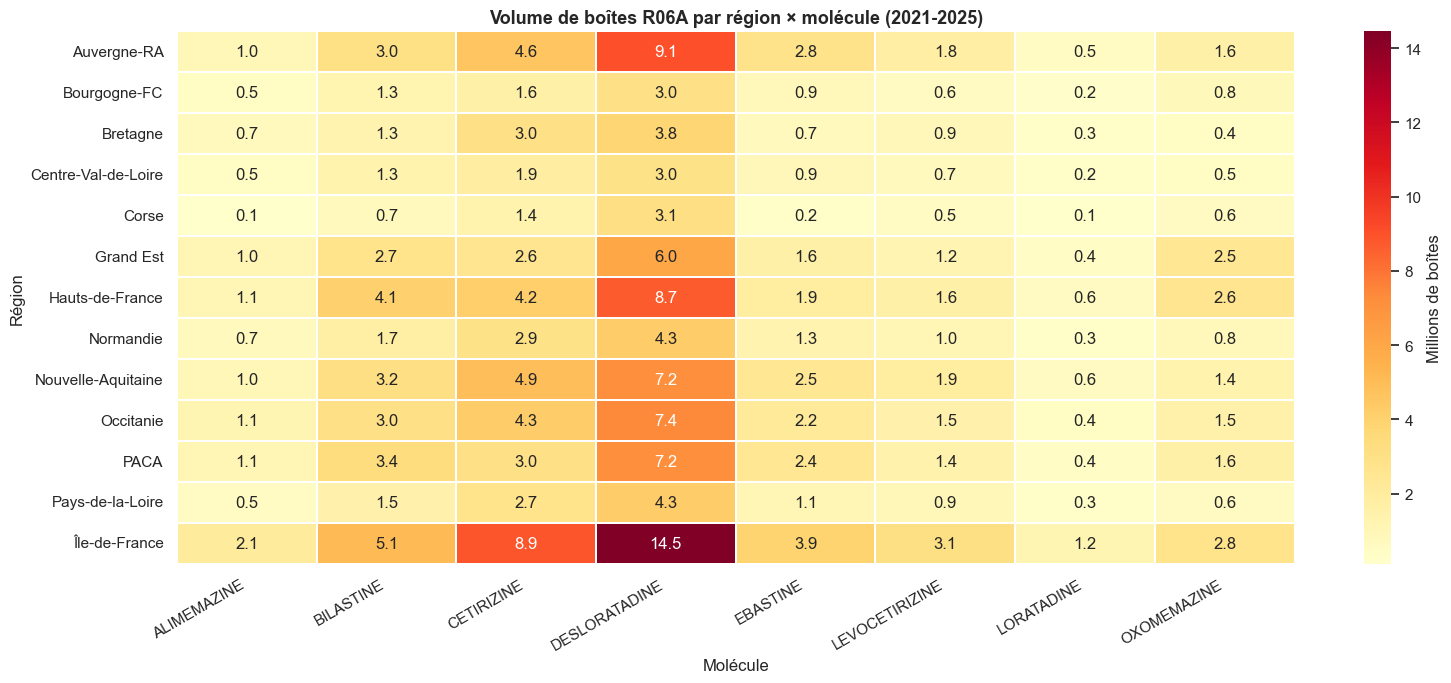

In [9]:
om_geo = om[~om['BEN_REG'].isin([0, 99])].copy()
top8_mol = boites_molecule.head(8)['L_ATC5'].tolist()
om_top = om_geo[om_geo['L_ATC5'].isin(top8_mol)]

heatmap_data = (om_top.groupby(['region_nom','L_ATC5'])['BOITES']
                .sum().unstack(fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'Millions de boîtes'})
ax.set_title('Volume de boîtes R06A par région × molécule (2021-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Molécule')
ax.set_ylabel('Région')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_09_heatmap_region_molecule.png', dpi=150, bbox_inches='tight')
plt.show()

## Synthèse — Insights clés

In [10]:
print('=' * 65)
print('SYNTHÈSE EDA — OPEN MEDIC & BDPM')
print('=' * 65)

boites_total = om['BOITES'].sum() / 1e6
croissance   = ((om[om['annee']==2025]['BOITES'].sum() - om[om['annee']==2021]['BOITES'].sum())
                / om[om['annee']==2021]['BOITES'].sum() * 100)
top_region   = om[~om['BEN_REG'].isin([0,99])].groupby('region_nom')['BOITES'].sum().idxmax()
top_mol      = om.groupby('L_ATC5')['BOITES'].sum().idxmax()
top_age      = om[om['age']!=99].groupby('age_label')['BOITES'].sum().idxmax()

print(f'  Volume total R06 (2021-2025)  : {boites_total:.0f}M boîtes')
print(f'  Croissance 2021->2025         : +{croissance:.0f}%')
print(f'  Région n°1                    : {top_region}')
print(f'  Molécule n°1                  : {top_mol}')
print(f"  Tranche d'âge dominante       : {top_age}")
print(f'  Indice de Gini marché         : {gini:.2f} — marché très concentré')
print()
print('  POINTS D ATTENTION POUR LE ML')
print('  --------------------------------')
print('  ⚠  BEN_REG -> mapper vers régions météo pour jointure Gold')
print('  ⚠  OpenMedic sans granularité mensuelle -> signal via pollen/météo')
print('  ⚠  Desloratadine : top ventes ET top ruptures — molécule la plus à risque')
print('  ℹ  Pas de pattern saisonnier stable -> enrichissement pollen/météo nécessaire')
print('  ℹ  Concentration marché : rupture Desloratadine = impact sur 33% des patients')


SYNTHÈSE EDA — OPEN MEDIC & BDPM
  Volume total R06 (2021-2025)  : 249M boîtes
  Croissance 2021->2025         : +15%
  Région n°1                    : Île-de-France
  Molécule n°1                  : DESLORATADINE
  Tranche d'âge dominante       : 20-59 ans
  Indice de Gini marché         : 0.63 — marché très concentré

  POINTS D ATTENTION POUR LE ML
  --------------------------------
  ⚠  BEN_REG -> mapper vers régions météo pour jointure Gold
  ⚠  OpenMedic sans granularité mensuelle -> signal via pollen/météo
  ⚠  Desloratadine : top ventes ET top ruptures — molécule la plus à risque
  ℹ  Pas de pattern saisonnier stable -> enrichissement pollen/météo nécessaire
  ℹ  Concentration marché : rupture Desloratadine = impact sur 33% des patients
